<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/preprocessing_keras_memory_safe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 환경설정


In [1]:
import tensorflow as tf

gpu_list = tf.config.list_physical_devices("GPU")
print("사용 가능한 GPU:", gpu_list)

사용 가능한 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
xgb_device = "cuda" if gpu_list else "cpu"
print("XGBoost device:", xgb_device)

XGBoost device: cuda


In [2]:
%pip install -q koreanize-matplotlib

import koreanize_matplotlib
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 19.0 MB/s eta 0:00:00


In [3]:
!apt-get update -qq
!apt-get install -qq fonts-nanum
!fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(plt.rcParams["font.family"])

In [5]:
import pandas as pd
import numpy as np

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [6]:
import sys

print("현재 Python:")
print(sys.executable)

!{sys.executable} -m pip install openpyxl

현재 Python:
/usr/bin/python3


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

file_path = "/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/Z-Alizadeh/extension of Z-Alizadeh sani dataset.xlsx"

df = pd.read_excel(file_path)

print("데이터 크기:", df.shape)

데이터 크기: (303, 59)


In [5]:
df.columns.tolist()

['Age',
 'Weight',
 'Length',
 'Sex',
 'BMI',
 'DM',
 'HTN',
 'Current Smoker',
 'EX-Smoker',
 'FH',
 'Obesity',
 'CRF',
 'CVA',
 'Airway disease',
 'Thyroid Disease',
 'CHF',
 'DLP',
 'BP',
 'PR',
 'Edema',
 'Weak Peripheral Pulse',
 'Lung rales',
 'Systolic Murmur',
 'Diastolic Murmur',
 'Typical Chest Pain',
 'Dyspnea',
 'Function Class',
 'Atypical',
 'Nonanginal',
 'Exertional CP',
 'LowTH Ang',
 'Q Wave',
 'St Elevation',
 'St Depression',
 'Tinversion',
 'LVH',
 'Poor R Progression',
 'BBB',
 'FBS',
 'CR',
 'TG',
 'LDL',
 'HDL',
 'BUN',
 'ESR',
 'HB',
 'K',
 'Na',
 'WBC',
 'Lymph',
 'Neut',
 'PLT',
 'EF-TTE',
 'Region RWMA',
 'VHD',
 'LAD',
 'LCX',
 'RCA',
 'Cath']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 59 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    303 non-null    int64  
 1   Weight                 303 non-null    int64  
 2   Length                 303 non-null    int64  
 3   Sex                    303 non-null    object 
 4   BMI                    303 non-null    float64
 5   DM                     303 non-null    int64  
 6   HTN                    303 non-null    int64  
 7   Current Smoker         303 non-null    int64  
 8   EX-Smoker              303 non-null    int64  
 9   FH                     303 non-null    int64  
 10  Obesity                303 non-null    object 
 11  CRF                    303 non-null    object 
 12  CVA                    303 non-null    object 
 13  Airway disease         303 non-null    object 
 14  Thyroid Disease        303 non-null    object 
 15  CHF   

In [7]:
df.isnull().sum()

,0
Age,0
Weight,0
Length,0
Sex,0
BMI,0
DM,0
HTN,0
Current Smoker,0
EX-Smoker,0
FH,0


In [13]:
# 문자열 컬럼 실제 값 확인
str_cols = df.select_dtypes(include='object').columns

for col in str_cols:
    print(f"\n[{col}]")
    print(df[col].value_counts(dropna=False))


[Sex]
Sex
Male     176
Fmale    127
Name: count, dtype: int64

[Obesity]
Obesity
Y    211
N     92
Name: count, dtype: int64

[CRF]
CRF
N    297
Y      6
Name: count, dtype: int64

[CVA]
CVA
N    298
Y      5
Name: count, dtype: int64

[Airway disease]
Airway disease
N    292
Y     11
Name: count, dtype: int64

[Thyroid Disease]
Thyroid Disease
N    296
Y      7
Name: count, dtype: int64

[CHF]
CHF
N    302
Y      1
Name: count, dtype: int64

[DLP]
DLP
N    191
Y    112
Name: count, dtype: int64

[Weak Peripheral Pulse]
Weak Peripheral Pulse
N    298
Y      5
Name: count, dtype: int64

[Lung rales]
Lung rales
N    292
Y     11
Name: count, dtype: int64

[Systolic Murmur]
Systolic Murmur
N    262
Y     41
Name: count, dtype: int64

[Diastolic Murmur]
Diastolic Murmur
N    294
Y      9
Name: count, dtype: int64

[Dyspnea]
Dyspnea
N    169
Y    134
Name: count, dtype: int64

[Atypical]
Atypical
N    210
Y     93
Name: count, dtype: int64

[Nonanginal]
Nonanginal
N    287
Y     16
Name: c

In [ ]:
int_cols = df.select_dtypes(include='int64').columns

for col in int_cols:
    print(f"\n{'='*40}")
    print(f"[{col}]")
    print(df[col].value_counts().sort_index())


[Age]
Age
30     2
36     1
38     2
40     1
41     3
42     4
43     4
44     4
45     2
46     5
47     9
48    12
49     9
50    17
51     8
52     9
53    10
54     6
55    18
56    15
57     8
58     6
59     7
60    12
61     3
62    15
63     7
64     9
65    11
66    12
67     7
68     6
69     3
70    12
71     5
72     6
73     5
74     3
75     5
76     7
77     2
79     2
80     4
81     3
85     1
86     1
Name: count, dtype: int64

[Weight]
Weight
48      2
50      3
51      1
53      3
54      5
55      4
56      2
57      4
58      3
59      2
60     11
61      6
62      5
63     10
64     11
65     10
66      9
67      8
68      7
69      3
70     16
71      5
72      8
73     10
74     12
75     22
76      8
77      2
78      8
79      6
80     16
81      7
82      9
83      5
84      7
85      6
86      2
87      3
88      6
89      7
90      7
91      2
92      3
93      1
94      1
95      2
97      2
98      3
100     2
102     1
103     1
105     1
108     2
12

01. 라이브러리
02. 데이터 불러오기
03. 데이터 구조 확인
04. 결측치 확인
05. Target 확인
06. 불필요/Leakage 변수 제거
07. 범주형 변수 Encoding
08. X / y 분리
09. Train / Test Split
10. Logistic Regression 전처리
11. Decision Tree 전처리
12. Logistic Regression Baseline
13. Decision Tree
14. 성능 비교

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
print(df['Cath'].value_counts())

Cath
CAD       216
Normal     87
Name: count, dtype: int64


In [ ]:
y = df['Cath'].map({
    'Normal': 0,
    'CAD': 1
})

print(y.value_counts())

# binary target
# Normal → 0
# CAD    → 1

Cath
1    216
0     87
Name: count, dtype: int64


In [ ]:
# leakgage / 불필요 변수 제거

drop_cols = [
    'Cath',
    'LAD',
    'LCX',
    'RCA',
    'Exertional CP'
]

X = df.drop(columns=drop_cols)

print("X 크기:", X.shape)

# Cath는 target으로 따로 사용했기 때문에 제거하고, LAD, LCX, RCA는 CAD 예측에 직접적인 결과 정보를 포함하므로 제외

X 크기: (303, 54)


In [ ]:
print(X.columns.tolist())

['Age', 'Weight', 'Length', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'BP', 'PR', 'Edema', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Typical Chest Pain', 'Dyspnea', 'Function Class', 'Atypical', 'Nonanginal', 'LowTH Ang', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'LVH', 'Poor R Progression', 'BBB', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA', 'VHD']


In [ ]:
# 범주형  처리
categorical_cols = [
    'Sex',
    'BBB',
    'VHD'
]

In [ ]:
# 숫자변환
binary_cols = [
    'Obesity',
    'CRF',
    'CVA',
    'Airway disease',
    'Thyroid Disease',
    'CHF',
    'DLP',
    'Weak Peripheral Pulse',
    'Lung rales',
    'Systolic Murmur',
    'Diastolic Murmur',
    'Dyspnea',
    'Atypical',
    'Nonanginal',
    'LowTH Ang',
    'LVH',
    'Poor R Progression'
]

In [ ]:
X = X.copy()

for col in binary_cols:
    X[col] = X[col].map({
        'N': 0,
        'Y': 1
    })

In [ ]:
X[binary_cols].head()

,Obesity,CRF,CVA,Airway disease,Thyroid Disease,CHF,DLP,Weak Peripheral Pulse,Lung rales,Systolic Murmur,Diastolic Murmur,Dyspnea,Atypical,Nonanginal,LowTH Ang,LVH,Poor R Progression
0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0
4,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0


In [ ]:
X['Sex'] = X['Sex'].map({
    'Male': 1,
    'Fmale': 0
})

In [ ]:
X['Sex'].value_counts()

,count
Sex,
1,176
0,127


In [ ]:
print(X.dtypes)

Age                        int64
Weight                     int64
Length                     int64
Sex                        int64
BMI                      float64
DM                         int64
HTN                        int64
Current Smoker             int64
EX-Smoker                  int64
FH                         int64
Obesity                    int64
CRF                        int64
CVA                        int64
Airway disease             int64
Thyroid Disease            int64
CHF                        int64
DLP                        int64
BP                         int64
PR                         int64
Edema                      int64
Weak Peripheral Pulse      int64
Lung rales                 int64
Systolic Murmur            int64
Diastolic Murmur           int64
Typical Chest Pain         int64
Dyspnea                    int64
Function Class             int64
Atypical                   int64
Nonanginal                 int64
LowTH Ang                  int64
Q Wave    

In [ ]:
print("\n문자열 컬럼:")
print(X.select_dtypes(include='object').columns.tolist())


문자열 컬럼:
['BBB', 'VHD']


In [ ]:
# train, test 나누기

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# stratify=y를 사용하면 Train과 Test에 CAD/Normal 비율이 최대한 동일하게 유지

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (242, 54)
X_test : (61, 54)
y_train: (242,)
y_test : (61,)


# 로지스틱 회귀 학습

In [ ]:
numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = ['BBB', 'VHD']

In [ ]:
lr_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ), categorical_cols)
    ]
)

In [ ]:
lr_model = Pipeline(
    steps=[
        ('preprocessor', lr_preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [ ]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Weight', 'Length',
                                                   'Sex', 'BMI', 'DM', 'HTN',
                                                   'Current Smoker',
                                                   'EX-Smoker', 'FH', 'Obesity',
                                                   'CRF', 'CVA',
                                                   'Airway disease',
                                                   'Thyroid Disease', 'CHF',
                                                   'DLP', 'BP', 'PR', 'Edema',
                                                   'Weak Peripheral Pulse',
                                                   'Lung rales',
                                                   'Systolic Murmur',
                                                   'Diastolic Murmur',
                                                   'Typical Chest Pain',
                                                   'Dyspnea', 'Function Class',
                                                   'Atypical', 'Nonanginal',
                                                   'LowTH Ang', ...]),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BBB', 'VHD'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.819672131147541


In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=== Logistic Regression Baseline ===")
print(f"Accuracy    : {accuracy_lr:.4f}")
print(f"Precision   : {precision_lr:.4f}")
print(f"Recall      : {recall_lr:.4f}")
print(f"F1-score    : {f1_lr:.4f}")
print(f"ROC-AUC     : {roc_auc_lr:.4f}")

=== Logistic Regression Baseline ===
Accuracy    : 0.8197
Precision   : 0.8636
Recall      : 0.8837
F1-score    : 0.8736
ROC-AUC     : 0.8850


In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[12  6]
 [ 5 38]]


In [ ]:
tn, fp, fn, tp = cm_lr.ravel()

specificity_lr = tn / (tn + fp)

print(f"Specificity : {specificity_lr:.4f}")

Specificity : 0.6667


In [ ]:
print("=== Logistic Regression Baseline ===")
print(f"Accuracy    : {accuracy_lr:.4f}")
print(f"Precision   : {precision_lr:.4f}")
print(f"Recall      : {recall_lr:.4f}")
print(f"Specificity : {specificity_lr:.4f}")
print(f"F1-score    : {f1_lr:.4f}")
print(f"ROC-AUC     : {roc_auc_lr:.4f}")

print("\n=== Confusion Matrix ===")
print(cm_lr)

=== Logistic Regression Baseline ===
Accuracy    : 0.8197
Precision   : 0.8636
Recall      : 0.8837
Specificity : 0.6667
F1-score    : 0.8736
ROC-AUC     : 0.8850

=== Confusion Matrix ===
[[12  6]
 [ 5 38]]


In [ ]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Normal', 'CAD']
))

              precision    recall  f1-score   support

      Normal       0.71      0.67      0.69        18
         CAD       0.86      0.88      0.87        43

    accuracy                           0.82        61
   macro avg       0.78      0.78      0.78        61
weighted avg       0.82      0.82      0.82        61



In [ ]:
lr_results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Accuracy': [accuracy_lr],
    'Precision': [precision_lr],
    'Sensitivity': [recall_lr],
    'Specificity': [specificity_lr],
    'F1-score': [f1_lr],
    'ROC-AUC': [roc_auc_lr]
})

lr_results

,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC
0,Logistic Regression,0.819672,0.863636,0.883721,0.666667,0.873563,0.885013


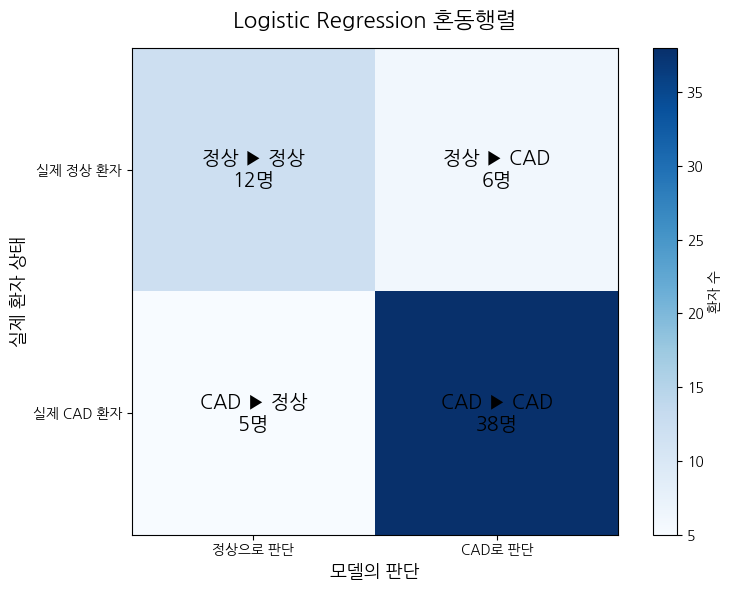

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression Confusion Matrix
cm_lr = np.array([
    [12, 6],
    [5, 38]
])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm_lr, cmap='Blues')

# 축 이름
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    '정상으로 판단',
    'CAD로 판단'
])

ax.set_yticklabels([
    '실제 정상 환자',
    '실제 CAD 환자'
])

# 각 칸에 숫자 + 설명
labels = [
    ['정상 ▶ 정상\n12명',
     '정상 ▶ CAD\n6명'],
    ['CAD ▶ 정상\n5명',
     'CAD ▶ CAD\n38명']
]

for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            labels[i][j],
            ha='center',
            va='center',
            fontsize=14
        )

ax.set_xlabel('모델의 판단', fontsize=13)
ax.set_ylabel('실제 환자 상태', fontsize=13)

ax.set_title(
    'Logistic Regression 혼동행렬',
    fontsize=16,
    pad=15
)

fig.colorbar(im, ax=ax, label='환자 수')

plt.tight_layout()
plt.show()

In [ ]:
# Decision Tree
dt_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(
            handle_unknown='ignore'
        ), categorical_cols)
    ]
)

dt_preprocessor

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['Age', 'Weight', 'Length', 'Sex', 'BMI', 'DM',
                                  'HTN', 'Current Smoker', 'EX-Smoker', 'FH',
                                  'Obesity', 'CRF', 'CVA', 'Airway disease',
                                  'Thyroid Disease', 'CHF', 'DLP', 'BP', 'PR',
                                  'Edema', 'Weak Peripheral Pulse',
                                  'Lung rales', 'Systolic Murmur',
                                  'Diastolic Murmur', 'Typical Chest Pain',
                                  'Dyspnea', 'Function Class', 'Atypical',
                                  'Nonanginal', 'LowTH Ang', ...]),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['BBB', 'VHD'])])

In [ ]:
dt_model = Pipeline(
    steps=[
        ('preprocessor', dt_preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

dt_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Weight', 'Length',
                                                   'Sex', 'BMI', 'DM', 'HTN',
                                                   'Current Smoker',
                                                   'EX-Smoker', 'FH', 'Obesity',
                                                   'CRF', 'CVA',
                                                   'Airway disease',
                                                   'Thyroid Disease', 'CHF',
                                                   'DLP', 'BP', 'PR', 'Edema',
                                                   'Weak Peripheral Pulse',
                                                   'Lung rales',
                                                   'Systolic Murmur',
                                                   'Diastolic Murmur',
                                                   'Typical Chest Pain',
                                                   'Dyspnea', 'Function Class',
                                                   'Atypical', 'Nonanginal',
                                                   'LowTH Ang', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BBB', 'VHD'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
# train 데이터로 학습 실시
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Weight', 'Length',
                                                   'Sex', 'BMI', 'DM', 'HTN',
                                                   'Current Smoker',
                                                   'EX-Smoker', 'FH', 'Obesity',
                                                   'CRF', 'CVA',
                                                   'Airway disease',
                                                   'Thyroid Disease', 'CHF',
                                                   'DLP', 'BP', 'PR', 'Edema',
                                                   'Weak Peripheral Pulse',
                                                   'Lung rales',
                                                   'Systolic Murmur',
                                                   'Diastolic Murmur',
                                                   'Typical Chest Pain',
                                                   'Dyspnea', 'Function Class',
                                                   'Atypical', 'Nonanginal',
                                                   'LowTH Ang', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BBB', 'VHD'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

y_prob_dt_train = dt_model.predict_proba(X_train)[:, 1]
y_prob_dt_test = dt_model.predict_proba(X_test)[:, 1]

print("Train 예측 개수 : ", len(y_pred_dt_train))
print("Test 예측 개수 : ", len(y_pred_dt_test))

Train 예측 개수 :  242
Test 예측 개수 :  61


In [ ]:
accuracy_dt_train = accuracy_score(y_train, y_pred_dt_train)
accuracy_dt_test = accuracy_score(y_test, y_pred_dt_test)

print("Decision Tree Baseline")
print(f"Train Accuracy : {accuracy_dt_train:.4f}")
print(f"Test Accuracy : {accuracy_dt_test:.4f}")
print(f"Accuracy Gap : {accuracy_dt_train - accuracy_dt_test:.4f}")

Decision Tree Baseline
Train Accuracy : 1.0000
Test Accuracy : 0.7049
Accuracy Gap : 0.2951


Train Accuracy 1.0000: 학습 데이터를 완전히 분류
Test Accuracy 0.7049: 새로운 데이터에서는 성능이 크게 하락
Gap 0.2951: 약 29.5%p 차이로, 제한 없는 트리가 학습 데이터를 지나치게 세분화한 상태
LR Test Accuracy 0.8197보다도 현재 DT가 낮음

In [ ]:
# DT baseline 성능 기록

accuracy_dt = accuracy_score(y_test, y_pred_dt_test)
precision_dt = precision_score(y_test, y_pred_dt_test)
recall_dt = recall_score(y_test, y_pred_dt_test)
f1_dt = f1_score(y_test, y_pred_dt_test)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt_test)

cm_dt = confusion_matrix(y_test, y_pred_dt_test)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()

specificity_dt = tn_dt / (tn_dt + fp_dt)

print("Decision Tree Baseline")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall : {recall_dt:.4f}")
print(f"Specificity : {specificity_dt:.4f}")
print(f"ROC-AUC : {roc_auc_dt:.4f}")

print("\n confusion matrix")
print(cm_dt)

Decision Tree Baseline
Accuracy : 0.7049
Precision : 0.8049
Recall : 0.7674
Specificity : 0.5556
ROC-AUC : 0.6615

 confusion matrix
[[10  8]
 [10 33]]


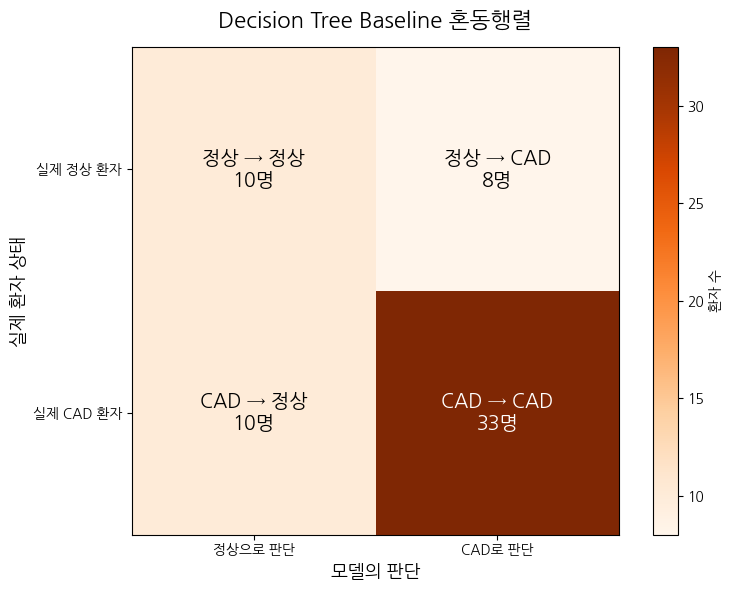

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm_dt, cmap='Oranges')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    '정상으로 판단',
    'CAD로 판단'
])

ax.set_yticklabels([
    '실제 정상 환자',
    '실제 CAD 환자'
])

labels = [
    [f'정상 → 정상\n{tn_dt}명',
     f'정상 → CAD\n{fp_dt}명'],
    [f'CAD → 정상\n{fn_dt}명',
     f'CAD → CAD\n{tp_dt}명']
]

threshold = cm_dt.max() / 2

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            labels[i][j],
            ha='center',
            va='center',
            fontsize=14,
            color='white' if cm_dt[i, j] > threshold else 'black'
        )

ax.set_xlabel('모델의 판단', fontsize=13)
ax.set_ylabel('실제 환자 상태', fontsize=13)
ax.set_title(
    'Decision Tree Baseline 혼동행렬',
    fontsize=16,
    pad=15
)

fig.colorbar(im, ax=ax, label='환자 수')

plt.tight_layout()
plt.show()

In [ ]:
# 탐색방법 및 후보값 정의

from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_dt = StratifiedKFold(
    n_splits = 5,
    shuffle=True,
    random_state = 42
)

param_grid_dt = {
    'model__criterion' : ['gini', 'entropy'],
    'model__max_depth' : [2, 3, 4, 5, 6],
    'model__min_samples_split' : [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 4, 8],
    'model__class_weight' : [None, 'balanced']
}

print("후보 조합 수 : ", 2*5*3*4*2)
print("교차검증을 포함한 총 학습 횟수", 2*5*3*4*2*5)


후보 조합 수 :  240
교차검증을 포함한 총 학습 횟수 1200


In [ ]:
grid_search_dt = GridSearchCV(
    estimator = dt_model,
    param_grid = param_grid_dt,
    scoring = 'roc_auc',
    cv = cv_dt,
    n_jobs = -1,
    return_train_score= True,
    refit = True,
    verbose = 1
)

grid_search_dt

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['Age',
                                                                          'Weight',
                                                                          'Length',
                                                                          'Sex',
                                                                          'BMI',
                                                                          'DM',
                                                                          'HTN',
                                                                          'Current '
                                                                          'Smoker',
                                                                          'EX-Smoker',
                                                                          'FH',
                                                                          'Obesity',
                                                                          'CRF',
                                                                          'CVA',
                                                                          'Airway '
                                                                          'disease',
                                                                          'Thyroid '
                                                                          'Disease',
                                                                          'CHF',
                                                                          'DLP',
                                                                          'BP',
                                                                          'PR',
                                                                          'Edema',
                                                                          'Weak '
                                                                          'Per...
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['BBB',
                                                                          'VHD'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [2, 3, 4, 5, 6],
                         'model__min_samples_leaf': [1, 2, 4, 8],
                         'model__min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [ ]:
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['Age',
                                                                          'Weight',
                                                                          'Length',
                                                                          'Sex',
                                                                          'BMI',
                                                                          'DM',
                                                                          'HTN',
                                                                          'Current '
                                                                          'Smoker',
                                                                          'EX-Smoker',
                                                                          'FH',
                                                                          'Obesity',
                                                                          'CRF',
                                                                          'CVA',
                                                                          'Airway '
                                                                          'disease',
                                                                          'Thyroid '
                                                                          'Disease',
                                                                          'CHF',
                                                                          'DLP',
                                                                          'BP',
                                                                          'PR',
                                                                          'Edema',
                                                                          'Weak '
                                                                          'Per...
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['BBB',
                                                                          'VHD'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [2, 3, 4, 5, 6],
                         'model__min_samples_leaf': [1, 2, 4, 8],
                         'model__min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [ ]:
best_index_dt = grid_search_dt.best_index_

best_cv_auc_dt = grid_search_dt.best_score_
best_train_auc_dt = grid_search_dt.cv_results_[
    'mean_train_score'
][best_index_dt]

print("=== Decision Tree Grid Search 결과 ===")
print("최적 하이퍼파라미터:")
print(grid_search_dt.best_params_)

print(f"\n평균 Train ROC-AUC : {best_train_auc_dt:.4f}")
print(f"평균 CV ROC-AUC    : {best_cv_auc_dt:.4f}")
print(
    f"Train-CV Gap       : "
    f"{best_train_auc_dt - best_cv_auc_dt:.4f}"
)

=== Decision Tree Grid Search 결과 ===
최적 하이퍼파라미터:
{'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 8, 'model__min_samples_split': 2}

평균 Train ROC-AUC : 0.9329
평균 CV ROC-AUC    : 0.8406
Train-CV Gap       : 0.0923


In [ ]:
# 최적 모델을 꺼내 동일한 train/test 데이터 예측값 생성

best_dt_model = grid_search_dt.best_estimator_

y_pred_dt_tuned_train = best_dt_model.predict(X_train)
y_pred_dt_tuned_test = best_dt_model.predict(X_test)
y_prob_dt_tuned_train = best_dt_model.predict_proba(
    X_train
)[:, 1]

y_prob_dt_tuned_test = best_dt_model.predict_proba(
    X_test
)[:, 1]

print("Train 예측 개수 : ", len(y_pred_dt_tuned_train))
print("Test 예측 개수 : ", len(y_pred_dt_tuned_test))

Train 예측 개수 :  242
Test 예측 개수 :  61


In [ ]:
# 튜닝 DT가 baseline보다 과적합이 줄었는지 확인

accuracy_dt_tuned_train = accuracy_score(
    y_train,
    y_pred_dt_tuned_train
)

accuracy_dt_tuned_test = accuracy_score(
    y_test,
    y_pred_dt_tuned_test
)

accuracy_gap_dt_tuned = (
    accuracy_dt_tuned_train - accuracy_dt_tuned_test
)

print("=== Tuned Decision Tree 과적합 확인 ===")
print(f"Train Accuracy : {accuracy_dt_tuned_train:.4f}")
print(f"Test Accuracy  : {accuracy_dt_tuned_test:.4f}")
print(f"Accuracy Gap   : {accuracy_gap_dt_tuned:.4f}")

=== Tuned Decision Tree 과적합 확인 ===
Train Accuracy : 0.8636
Test Accuracy  : 0.8525
Accuracy Gap   : 0.0112


In [ ]:
accuracy_dt_tuned = accuracy_score(
    y_test,
    y_pred_dt_tuned_test
)

precision_dt_tuned = precision_score(
    y_test,
    y_pred_dt_tuned_test
)

recall_dt_tuned = recall_score(
    y_test,
    y_pred_dt_tuned_test
)

f1_dt_tuned = f1_score(
    y_test,
    y_pred_dt_tuned_test
)

roc_auc_dt_tuned = roc_auc_score(
    y_test,
    y_prob_dt_tuned_test
)

cm_dt_tuned = confusion_matrix(
    y_test,
    y_pred_dt_tuned_test
)

tn_dt_tuned, fp_dt_tuned, fn_dt_tuned, tp_dt_tuned = (
    cm_dt_tuned.ravel()
)

specificity_dt_tuned = (
    tn_dt_tuned / (tn_dt_tuned + fp_dt_tuned)
)

print("=== Tuned Decision Tree ===")
print(f"Accuracy    : {accuracy_dt_tuned:.4f}")
print(f"Precision   : {precision_dt_tuned:.4f}")
print(f"Recall      : {recall_dt_tuned:.4f}")
print(f"Specificity : {specificity_dt_tuned:.4f}")
print(f"F1-score    : {f1_dt_tuned:.4f}")
print(f"ROC-AUC     : {roc_auc_dt_tuned:.4f}")

print("\n=== Confusion Matrix ===")
print(cm_dt_tuned)

=== Tuned Decision Tree ===
Accuracy    : 0.8525
Precision   : 0.8696
Recall      : 0.9302
Specificity : 0.6667
F1-score    : 0.8989
ROC-AUC     : 0.8411

=== Confusion Matrix ===
[[12  6]
 [ 3 40]]


In [ ]:
model_comparison = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy': accuracy_lr,
        'Precision': precision_lr,
        'Recall': recall_lr,
        'Specificity': specificity_lr,
        'F1-score': f1_lr,
        'ROC-AUC': roc_auc_lr
    },
    'DT Baseline': {
        'Accuracy': accuracy_dt,
        'Precision': precision_dt,
        'Recall': recall_dt,
        'Specificity': specificity_dt,
        'F1-score': f1_dt,
        'ROC-AUC': roc_auc_dt
    },
    'DT Tuned': {
        'Accuracy': accuracy_dt_tuned,
        'Precision': precision_dt_tuned,
        'Recall': recall_dt_tuned,
        'Specificity': specificity_dt_tuned,
        'F1-score': f1_dt_tuned,
        'ROC-AUC': roc_auc_dt_tuned
    }
}).T

model_comparison.round(4)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC
Logistic Regression,0.8197,0.8636,0.8837,0.6667,0.8736,0.8850
DT Baseline,0.7049,0.8049,0.7674,0.5556,0.7857,0.6615
DT Tuned,0.8525,0.8696,0.9302,0.6667,0.8989,0.8411


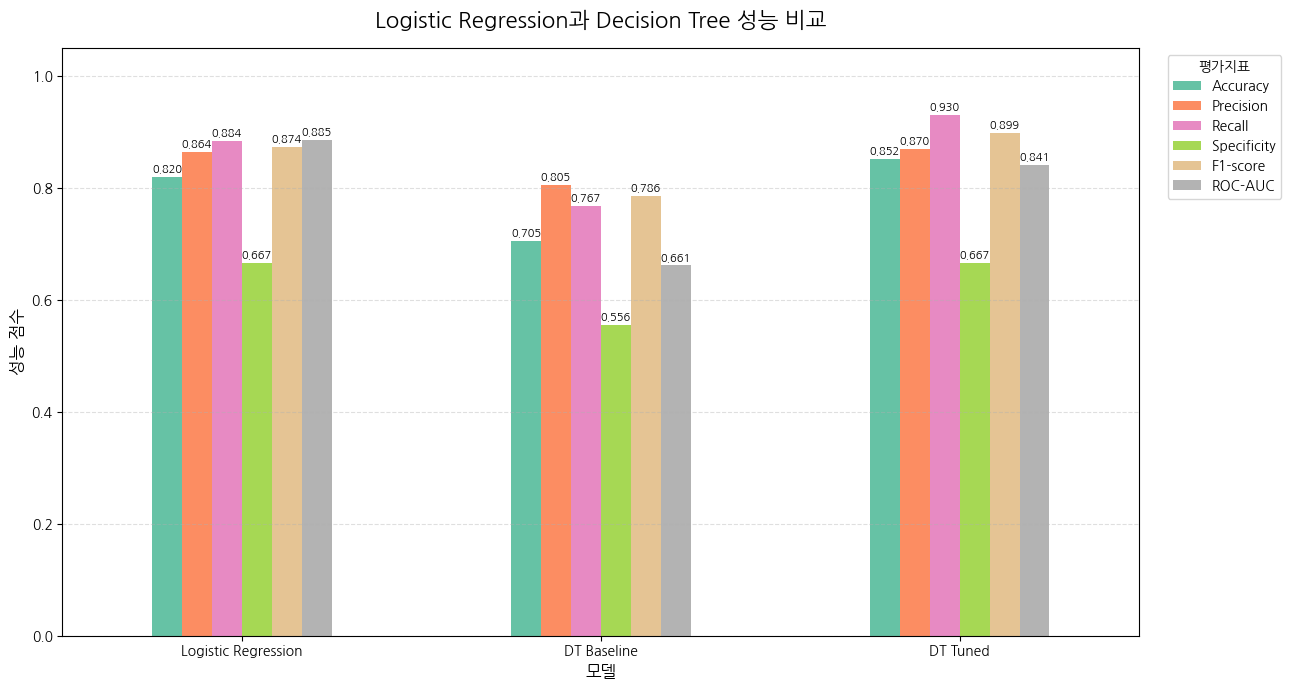

In [ ]:
ax = model_comparison.plot(
    kind='bar',
    figsize=(13, 7),
    ylim=(0, 1.05),
    rot=0,
    colormap='Set2'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        fontsize=8,
        padding=2
    )

ax.set_title(
    'Logistic Regression과 Decision Tree 성능 비교',
    fontsize=16,
    pad=15
)

ax.set_xlabel('모델', fontsize=12)
ax.set_ylabel('성능 점수', fontsize=12)

ax.legend(
    title='평가지표',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
feature_names_dt = (
    best_dt_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

feature_importance_dt = (
    best_dt_model
    .named_steps['model']
    .feature_importances_
)

importance_df_dt = pd.DataFrame({
    'Feature': feature_names_dt,
    'Importance': feature_importance_dt
})

importance_df_dt['Feature'] = (
    importance_df_dt['Feature']
    .str.replace(r'^(num|cat)__', '', regex=True)
)

importance_df_dt = (
    importance_df_dt
    .sort_values(
        by='Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df_dt.head(15)

,Feature,Importance
0,Typical Chest Pain,0.585824
1,Region RWMA,0.138006
2,Age,0.090021
3,HDL,0.069564
4,ESR,0.065556
5,BMI,0.051029
6,Length,0.000000
7,Current Smoker,0.000000
8,Sex,0.000000
9,DM,0.000000


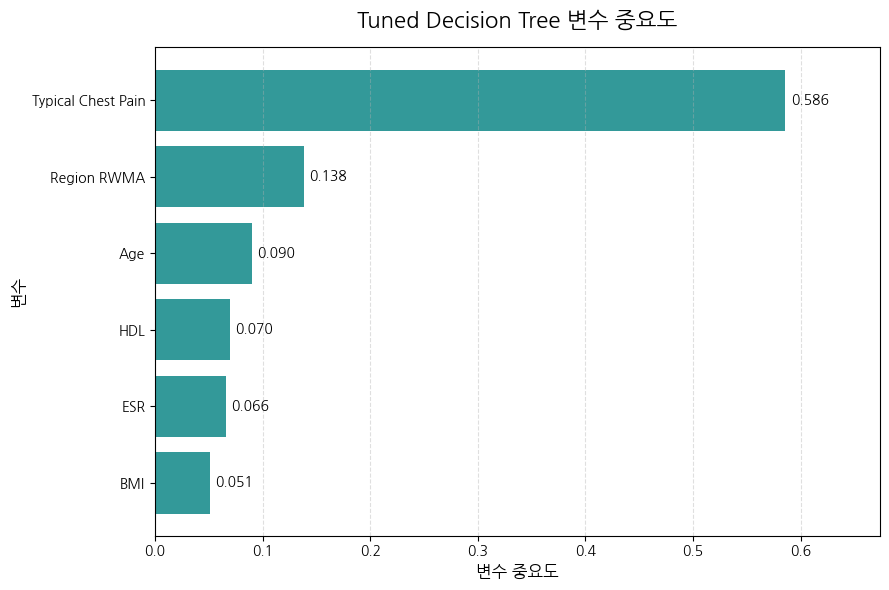

In [ ]:
importance_nonzero_dt = (
    importance_df_dt[
        importance_df_dt['Importance'] > 0
    ]
    .sort_values(
        by='Importance',
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    importance_nonzero_dt['Feature'],
    importance_nonzero_dt['Importance'],
    color='teal',
    alpha=0.8
)

ax.bar_label(
    bars,
    fmt='%.3f',
    padding=4,
    fontsize=10
)

ax.set_title(
    'Tuned Decision Tree 변수 중요도',
    fontsize=16,
    pad=15
)

ax.set_xlabel('변수 중요도', fontsize=12)
ax.set_ylabel('변수', fontsize=12)

ax.set_xlim(
    0,
    importance_nonzero_dt['Importance'].max() * 1.15
)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[]


In [9]:
import gc
import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    StratifiedKFold,
    ParameterSampler,
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import tensorflow as tf


SEED = 42
MIN_SENSITIVITY = 0.95
N_ECE_BINS = 10

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

##원본데이터 정리

In [10]:
# 반드시 원본 df에서 새로 생성
df_model = df.copy()

y_final = df_model['Cath'].map({
    'Normal': 0,
    'CAD': 1
}).astype(int)

drop_cols_final = [
    'Cath',
    'LAD',
    'LCX',
    'RCA',
    'Exertional CP'
]

X_final = df_model.drop(
    columns=drop_cols_final
).copy()

binary_cols_final = [
    'Obesity',
    'CRF',
    'CVA',
    'Airway disease',
    'Thyroid Disease',
    'CHF',
    'DLP',
    'Weak Peripheral Pulse',
    'Lung rales',
    'Systolic Murmur',
    'Diastolic Murmur',
    'Dyspnea',
    'Atypical',
    'Nonanginal',
    'LowTH Ang',
    'LVH',
    'Poor R Progression'
]

for col in binary_cols_final:
    X_final[col] = X_final[col].map({
        'N': 0,
        'Y': 1
    })

X_final['Sex'] = X_final['Sex'].map({
    'Fmale': 0,
    'Male': 1
})

X_final = X_final.reset_index(drop=True)
y_final = y_final.reset_index(drop=True)

assert X_final.shape == (303, 54)
assert y_final.value_counts().to_dict() == {1: 216, 0: 87}
assert X_final.isna().sum().sum() == 0

assert set(X_final['BBB'].unique()).issubset({
    'N', 'LBBB', 'RBBB'
})

assert set(X_final['VHD'].unique()).issubset({
    'N', 'mild', 'Moderate', 'Severe'
})

print("X:", X_final.shape)
print("y:", y_final.shape)
print(y_final.value_counts())

X: (303, 54)
y: (303,)
Cath
1    216
0     87
Name: count, dtype: int64


##공통전처리기

In [11]:
categorical_bbb = ['BBB']
ordinal_vhd = ['VHD']

numeric_cols_final = [
    col for col in X_final.columns
    if col not in categorical_bbb + ordinal_vhd
]

def make_final_preprocessor(scale_numeric=False):
    numeric_transformer = (
        StandardScaler()
        if scale_numeric
        else 'passthrough'
    )

    return ColumnTransformer(
        transformers=[
            (
                'num',
                numeric_transformer,
                numeric_cols_final
            ),
            (
                'bbb',
                OneHotEncoder(
                    categories=[[
                        'N',
                        'LBBB',
                        'RBBB'
                    ]],
                    drop=['N'],
                    handle_unknown='ignore',
                    sparse_output=False
                ),
                categorical_bbb
            ),
            (
                'vhd',
                OrdinalEncoder(
                    categories=[[
                        'N',
                        'mild',
                        'Moderate',
                        'Severe'
                    ]],
                    handle_unknown='use_encoded_value',
                    unknown_value=-1
                ),
                ordinal_vhd
            )
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )

print("원본 입력 변수:", len(X_final.columns))
print("예상 전처리 후 변수: 55")

원본 입력 변수: 54
예상 전처리 후 변수: 55


## 공통 threshold 및 평가 함수

In [12]:
def safe_divide(numerator, denominator):
    if denominator == 0:
        return 0.0

    return numerator / denominator


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=N_ECE_BINS
):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    bin_ids = np.digitize(
        y_prob,
        bin_edges[1:-1],
        right=True
    )

    ece = 0.0
    n = len(y_true)

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id

        if not np.any(mask):
            continue

        bin_accuracy = y_true[mask].mean()
        bin_confidence = y_prob[mask].mean()
        bin_weight = mask.sum() / n

        ece += (
            bin_weight
            * abs(bin_accuracy - bin_confidence)
        )

    return float(ece)


def calculate_binary_metrics(
    y_true,
    y_prob,
    threshold=None,
    y_pred=None
):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if y_pred is None:
        if threshold is None:
            raise ValueError(
                "threshold 또는 y_pred가 필요합니다."
            )

        y_pred = (
            y_prob >= threshold
        ).astype(int)

    y_pred = np.asarray(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = safe_divide(
        tp,
        tp + fn
    )

    specificity = safe_divide(
        tn,
        tn + fp
    )

    # Binary Brier score
    brier = np.mean(
        (y_true - y_prob) ** 2
    )

    return {
        'Threshold': (
            float(threshold)
            if threshold is not None
            else np.nan
        ),
        'Accuracy': accuracy_score(
            y_true,
            y_pred
        ),
        'Precision': precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1': f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        'PR_AUC': average_precision_score(
            y_true,
            y_prob
        ),
        'ROC_AUC': roc_auc_score(
            y_true,
            y_prob
        ),
        'Brier': float(brier),
        'ECE': expected_calibration_error(
            y_true,
            y_prob
        ),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    }


def select_clinical_threshold(
    y_true,
    y_prob,
    min_sensitivity=MIN_SENSITIVITY
):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    candidate_thresholds = np.unique(
        np.concatenate([
            np.array([0.0]),
            y_prob,
            np.array([1.0])
        ])
    )

    candidates = []

    for threshold in candidate_thresholds:
        y_pred = (
            y_prob >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        sensitivity = safe_divide(
            tp,
            tp + fn
        )

        specificity = safe_divide(
            tn,
            tn + fp
        )

        if sensitivity >= min_sensitivity:
            candidates.append({
                'Threshold': float(threshold),
                'Sensitivity': sensitivity,
                'Specificity': specificity
            })

    if not candidates:
        raise RuntimeError(
            "Sensitivity 조건을 만족하는 "
            "threshold가 없습니다."
        )

    # Sensitivity 95% 이상을 만족한 후보 중
    # Specificity 최대화
    best = max(
        candidates,
        key=lambda row: (
            row['Specificity'],
            row['Sensitivity'],
            row['Threshold']
        )
    )

    return best['Threshold']

## XGBoost/RF 공통 Nested CV 함수

In [13]:
OUTER_CV = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

INNER_CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

FINAL_METRIC_COLUMNS = [
    'Threshold',
    'Accuracy',
    'Precision',
    'Sensitivity',
    'Specificity',
    'F1',
    'PR_AUC',
    'ROC_AUC',
    'Brier',
    'ECE',
    'TN',
    'FP',
    'FN',
    'TP'
]


def nested_cv_sklearn_model(
    X,
    y,
    base_model,
    param_distributions,
    model_name,
    n_iter=20,
    scale_numeric=False
):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    outer_oof_prob = np.zeros(
        len(y),
        dtype=float
    )

    outer_oof_pred = np.zeros(
        len(y),
        dtype=int
    )

    fold_results = []
    selected_params = []

    sampled_params = list(
        ParameterSampler(
            param_distributions,
            n_iter=n_iter,
            random_state=SEED
        )
    )

    for outer_fold, (
        outer_train_idx,
        outer_test_idx
    ) in enumerate(
        OUTER_CV.split(X, y),
        start=1
    ):
        print(
            f"[{model_name}] "
            f"Outer fold {outer_fold}/10"
        )

        X_outer_train = (
            X.iloc[outer_train_idx]
            .reset_index(drop=True)
        )

        y_outer_train = (
            y.iloc[outer_train_idx]
            .reset_index(drop=True)
        )

        X_outer_test = (
            X.iloc[outer_test_idx]
            .reset_index(drop=True)
        )

        y_outer_test = (
            y.iloc[outer_test_idx]
            .reset_index(drop=True)
        )

        best_candidate = None

        for params in sampled_params:
            inner_oof_prob = np.zeros(
                len(y_outer_train),
                dtype=float
            )

            for (
                inner_train_idx,
                inner_val_idx
            ) in INNER_CV.split(
                X_outer_train,
                y_outer_train
            ):
                X_inner_train = X_outer_train.iloc[
                    inner_train_idx
                ]

                y_inner_train = y_outer_train.iloc[
                    inner_train_idx
                ]

                X_inner_val = X_outer_train.iloc[
                    inner_val_idx
                ]

                estimator = clone(
                    base_model
                ).set_params(**params)

                pipeline = Pipeline([
                    (
                        'preprocessor',
                        make_final_preprocessor(
                            scale_numeric=scale_numeric
                        )
                    ),
                    (
                        'model',
                        estimator
                    )
                ])

                pipeline.fit(
                    X_inner_train,
                    y_inner_train
                )

                inner_oof_prob[
                    inner_val_idx
                ] = pipeline.predict_proba(
                    X_inner_val
                )[:, 1]

            threshold = select_clinical_threshold(
                y_outer_train,
                inner_oof_prob
            )

            inner_metrics = (
                calculate_binary_metrics(
                    y_outer_train,
                    inner_oof_prob,
                    threshold=threshold
                )
            )

            # Sensitivity는 threshold 선택에서
            # 이미 95% 이상으로 강제됨.
            candidate_rank = (
                inner_metrics['Specificity'],
                inner_metrics['PR_AUC'],
                inner_metrics['ROC_AUC'],
                -inner_metrics['Brier'],
                -inner_metrics['ECE']
            )

            if (
                best_candidate is None
                or candidate_rank
                > best_candidate['Rank']
            ):
                best_candidate = {
                    'Params': params,
                    'Threshold': threshold,
                    'InnerMetrics': inner_metrics,
                    'Rank': candidate_rank
                }

        best_params = best_candidate['Params']
        best_threshold = (
            best_candidate['Threshold']
        )

        selected_params.append(best_params)

        final_estimator = clone(
            base_model
        ).set_params(**best_params)

        final_pipeline = Pipeline([
            (
                'preprocessor',
                make_final_preprocessor(
                    scale_numeric=scale_numeric
                )
            ),
            (
                'model',
                final_estimator
            )
        ])

        final_pipeline.fit(
            X_outer_train,
            y_outer_train
        )

        outer_prob = final_pipeline.predict_proba(
            X_outer_test
        )[:, 1]

        outer_pred = (
            outer_prob >= best_threshold
        ).astype(int)

        outer_oof_prob[
            outer_test_idx
        ] = outer_prob

        outer_oof_pred[
            outer_test_idx
        ] = outer_pred

        fold_metrics = calculate_binary_metrics(
            y_outer_test,
            outer_prob,
            threshold=best_threshold,
            y_pred=outer_pred
        )

        fold_results.append({
            'OuterFold': outer_fold,
            **fold_metrics,
            'BestParams': best_params
        })

    fold_results_df = pd.DataFrame(
        fold_results
    )

    summary = (
        fold_results_df[
            FINAL_METRIC_COLUMNS
        ]
        .agg(['mean', 'std'])
        .T
        .rename(
            columns={
                'mean': 'Mean',
                'std': 'SD'
            }
        )
    )

    pooled_metrics = (
        calculate_binary_metrics(
            y,
            outer_oof_prob,
            y_pred=outer_oof_pred
        )
    )

    return {
        'Model': model_name,
        'FoldResults': fold_results_df,
        'Summary': summary,
        'PooledMetrics': pooled_metrics,
        'OOFProbability': outer_oof_prob,
        'OOFPrediction': outer_oof_pred,
        'SelectedParams': selected_params
    }

## XGboost 실행

In [ ]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

xgb_param_distributions = {
    'n_estimators': [
        100,
        200,
        300,
        500
    ],
    'max_depth': [
        2,
        3,
        4,
        5
    ],
    'learning_rate': [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    'min_child_weight': [
        1,
        3,
        5,
        10
    ],
    'subsample': [
        0.7,
        0.85,
        1.0
    ],
    'colsample_bytree': [
        0.7,
        0.85,
        1.0
    ],
    'reg_alpha': [
        0.0,
        0.1,
        1.0
    ],
    'reg_lambda': [
        1.0,
        5.0,
        10.0
    ]
}

xgb_nested = nested_cv_sklearn_model(
    X=X_final,
    y=y_final,
    base_model=xgb_base,
    param_distributions=(
        xgb_param_distributions
    ),
    model_name='XGBoost',
    n_iter=24,
    scale_numeric=False
)

[XGBoost] Outer fold 1/10
[XGBoost] Outer fold 2/10
[XGBoost] Outer fold 3/10
[XGBoost] Outer fold 4/10
[XGBoost] Outer fold 5/10
[XGBoost] Outer fold 6/10
[XGBoost] Outer fold 7/10
[XGBoost] Outer fold 8/10
[XGBoost] Outer fold 9/10
[XGBoost] Outer fold 10/10


In [ ]:
# 결과확인
display(
    xgb_nested['Summary'].round(4)
)

print("\nPooled outer OOF metrics")
display(
    pd.Series(
        xgb_nested['PooledMetrics']
    ).round(4)
)

print("\nOuter fold별 선택 파라미터")
display(
    xgb_nested['FoldResults'][
        [
            'OuterFold',
            'Threshold',
            'Sensitivity',
            'Specificity',
            'PR_AUC',
            'ROC_AUC',
            'BestParams'
        ]
    ]
)

,Mean,SD
Threshold,0.4411,0.0636
Accuracy,0.8445,0.0760
Precision,0.8579,0.0722
Sensitivity,0.9437,0.0489
Specificity,0.5944,0.2129
F1,0.8972,0.0486
PR_AUC,0.9622,0.0357
ROC_AUC,0.9172,0.0691
Brier,0.1112,0.0502
ECE,0.1484,0.0413



Pooled outer OOF metrics


,0
Threshold,NaN
Accuracy,0.8449
Precision,0.8536
Sensitivity,0.9444
Specificity,0.5977
F1,0.8967
PR_AUC,0.9513
ROC_AUC,0.9012
Brier,0.1109
ECE,0.0494



Outer fold별 선택 파라미터


,OuterFold,Threshold,Sensitivity,Specificity,PR_AUC,ROC_AUC,BestParams
0,1,0.451606,1.000000,0.666667,0.994146,0.984848,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alp..."
1,2,0.447844,0.909091,0.777778,0.988864,0.969697,"{'subsample': 1.0, 'reg_lambda': 10.0, 'reg_al..."
2,3,0.431650,1.000000,0.555556,0.906690,0.878788,"{'subsample': 0.85, 'reg_lambda': 10.0, 'reg_a..."
3,4,0.406942,1.000000,0.625000,0.992479,0.977273,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alp..."
4,5,0.384997,0.954545,0.500000,0.958344,0.892045,"{'subsample': 0.85, 'reg_lambda': 10.0, 'reg_a..."
5,6,0.572298,0.954545,0.375000,0.959667,0.897727,"{'subsample': 0.7, 'reg_lambda': 10.0, 'reg_al..."
6,7,0.332687,0.952381,0.666667,0.988575,0.968254,"{'subsample': 0.85, 'reg_lambda': 10.0, 'reg_a..."
7,8,0.431490,0.904762,1.000000,0.981481,0.947090,"{'subsample': 0.85, 'reg_lambda': 10.0, 'reg_a..."
8,9,0.488905,0.857143,0.222222,0.894075,0.756614,"{'subsample': 1.0, 'reg_lambda': 10.0, 'reg_al..."
9,10,0.462469,0.904762,0.555556,0.957763,0.899471,"{'subsample': 0.85, 'reg_lambda': 10.0, 'reg_a..."


In [14]:
# Random Forest 실행
rf_base = RandomForestClassifier(
    random_state=SEED,
    n_jobs=-1
)

rf_param_distributions = {
    'n_estimators': [
        200,
        400,
        600
    ],
    'max_depth': [
        None,
        3,
        5,
        8,
        12
    ],
    'min_samples_split': [
        2,
        5,
        10,
        20
    ],
    'min_samples_leaf': [
        1,
        2,
        4,
        8
    ],
    'max_features': [
        'sqrt',
        'log2',
        0.5,
        None
    ],
    'class_weight': [
        None,
        'balanced',
        'balanced_subsample'
    ],
    'criterion': [
        'gini',
        'entropy'
    ]
}

rf_nested = nested_cv_sklearn_model(
    X=X_final,
    y=y_final,
    base_model=rf_base,
    param_distributions=(
        rf_param_distributions
    ),
    model_name='Random Forest',
    n_iter=24,
    scale_numeric=False
)

[Random Forest] Outer fold 1/10
[Random Forest] Outer fold 2/10
[Random Forest] Outer fold 3/10
[Random Forest] Outer fold 4/10
[Random Forest] Outer fold 5/10
[Random Forest] Outer fold 6/10
[Random Forest] Outer fold 7/10
[Random Forest] Outer fold 8/10
[Random Forest] Outer fold 9/10
[Random Forest] Outer fold 10/10


In [15]:
# 결과 확인
display(
    rf_nested['Summary'].round(4)
)

print("\nPooled outer OOF metrics")
display(
    pd.Series(
        rf_nested['PooledMetrics']
    ).round(4)
)

print("\nOuter fold별 선택 파라미터")
display(
    rf_nested['FoldResults'][
        [
            'OuterFold',
            'Threshold',
            'Sensitivity',
            'Specificity',
            'PR_AUC',
            'ROC_AUC',
            'BestParams'
        ]
    ]
)

,Mean,SD
Threshold,0.4734,0.0665
Accuracy,0.8775,0.0503
Precision,0.8856,0.0422
Sensitivity,0.9528,0.0550
Specificity,0.6889,0.1197
F1,0.9169,0.0356
PR_AUC,0.9706,0.0258
ROC_AUC,0.9290,0.0604
Brier,0.1235,0.0307
ECE,0.2042,0.0482



Pooled outer OOF metrics


,0
Threshold,NaN
Accuracy,0.8779
Precision,0.8841
Sensitivity,0.9537
Specificity,0.6897
F1,0.9176
PR_AUC,0.9709
ROC_AUC,0.9278
Brier,0.1233
ECE,0.1590



Outer fold별 선택 파라미터


,OuterFold,Threshold,Sensitivity,Specificity,PR_AUC,ROC_AUC,BestParams
0,1,0.507449,1.000000,0.777778,0.992260,0.979798,"{'n_estimators': 600, 'min_samples_split': 2, ..."
1,2,0.440333,1.000000,0.777778,1.000000,1.000000,"{'n_estimators': 600, 'min_samples_split': 2, ..."
2,3,0.410720,1.000000,0.555556,0.943575,0.893939,"{'n_estimators': 400, 'min_samples_split': 10,..."
3,4,0.425705,1.000000,0.625000,1.000000,1.000000,"{'n_estimators': 400, 'min_samples_split': 20,..."
4,5,0.568635,0.954545,0.625000,0.957611,0.886364,"{'n_estimators': 600, 'min_samples_split': 10,..."
5,6,0.447563,0.954545,0.750000,0.973041,0.931818,"{'n_estimators': 600, 'min_samples_split': 20,..."
6,7,0.424248,0.952381,0.777778,0.981042,0.952381,"{'n_estimators': 200, 'min_samples_split': 5, ..."
7,8,0.607530,0.857143,0.888889,0.978371,0.941799,"{'n_estimators': 600, 'min_samples_split': 10,..."
8,9,0.458244,0.857143,0.555556,0.919225,0.804233,"{'n_estimators': 200, 'min_samples_split': 5, ..."
9,10,0.443137,0.952381,0.555556,0.960679,0.899471,"{'n_estimators': 200, 'min_samples_split': 5, ..."


In [16]:
from pathlib import Path
from datetime import datetime
import hashlib
import json
import platform

import joblib
import numpy as np
import pandas as pd
import sklearn

# 1. 저장 폴더 생성
DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

if not DRIVE_ROOT.exists():
    raise RuntimeError(
        "Google Drive가 연결되지 않았습니다."
    )

run_id = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

RF_SAVE_DIR = (
    DRIVE_ROOT
    / "clinical_rf_validation"
    / f"rf_nested_{run_id}"
)

RF_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=False
)

print("저장 위치:")
print(RF_SAVE_DIR)


# 2. JSON 변환 보조 함수
def json_default(value):
    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    return str(value)


# 3. Summary 저장
rf_nested["Summary"].to_csv(
    RF_SAVE_DIR / "rf_nested_summary.csv",
    encoding="utf-8-sig"
)


# 4. Pooled metrics 저장
pd.Series(
    rf_nested["PooledMetrics"],
    name="Value"
).to_csv(
    RF_SAVE_DIR / "rf_pooled_metrics.csv",
    encoding="utf-8-sig"
)

with open(
    RF_SAVE_DIR / "rf_pooled_metrics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        rf_nested["PooledMetrics"],
        file,
        ensure_ascii=False,
        indent=2,
        default=json_default
    )


# 5. Outer fold 결과 저장
rf_nested["FoldResults"].to_csv(
    RF_SAVE_DIR / "rf_outer_fold_results.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    RF_SAVE_DIR / "rf_outer_fold_results.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        rf_nested[
            "FoldResults"
        ].to_dict(orient="records"),
        file,
        ensure_ascii=False,
        indent=2,
        default=json_default
    )


# 6. Fold별 선택 파라미터 저장
with open(
    RF_SAVE_DIR / "rf_selected_params.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        rf_nested["SelectedParams"],
        file,
        ensure_ascii=False,
        indent=2,
        default=json_default
    )


# 7. 각 환자의 Outer fold와 적용 threshold 복원
outer_fold_per_row = np.zeros(
    len(y_final),
    dtype=int
)

threshold_per_row = np.zeros(
    len(y_final),
    dtype=float
)

outer_split_records = []

for outer_fold, (
    train_idx,
    test_idx
) in enumerate(
    OUTER_CV.split(X_final, y_final),
    start=1
):
    fold_threshold = float(
        rf_nested["FoldResults"]
        .loc[
            rf_nested["FoldResults"][
                "OuterFold"
            ] == outer_fold,
            "Threshold"
        ]
        .iloc[0]
    )

    outer_fold_per_row[test_idx] = (
        outer_fold
    )

    threshold_per_row[test_idx] = (
        fold_threshold
    )

    outer_split_records.append({
        "OuterFold": outer_fold,
        "TrainIndices": train_idx.tolist(),
        "TestIndices": test_idx.tolist()
    })


# 8. OOF 예측값 저장
rf_oof_df = pd.DataFrame({
    "RowIndex": np.arange(len(y_final)),
    "OuterFold": outer_fold_per_row,
    "TrueLabel": np.asarray(y_final),
    "OOFProbability": (
        rf_nested["OOFProbability"]
    ),
    "AppliedThreshold": threshold_per_row,
    "OOFPrediction": (
        rf_nested["OOFPrediction"]
    )
})

rf_oof_df.to_csv(
    RF_SAVE_DIR / "rf_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

np.savez_compressed(
    RF_SAVE_DIR / "rf_oof_predictions.npz",
    row_index=np.arange(len(y_final)),
    outer_fold=outer_fold_per_row,
    y_true=np.asarray(y_final),
    probability=rf_nested[
        "OOFProbability"
    ],
    threshold=threshold_per_row,
    prediction=rf_nested[
        "OOFPrediction"
    ]
)


# 9. 실제 Outer split 인덱스 저장
with open(
    RF_SAVE_DIR / "rf_outer_splits.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        outer_split_records,
        file,
        ensure_ascii=False,
        indent=2
    )


# 10. RF 후보와 실험 설정 저장
rf_sampled_params = list(
    ParameterSampler(
        rf_param_distributions,
        n_iter=24,
        random_state=SEED
    )
)

experiment_config = {
    "Model": "RandomForestClassifier",
    "Seed": SEED,
    "MinimumSensitivity": (
        MIN_SENSITIVITY
    ),
    "ECEBins": N_ECE_BINS,
    "OuterFolds": OUTER_CV.n_splits,
    "InnerFolds": INNER_CV.n_splits,
    "CandidateCount": len(
        rf_sampled_params
    ),
    "RawInputCount": X_final.shape[1],
    "SampleCount": len(y_final),
    "TargetDistribution": (
        y_final.value_counts()
        .sort_index()
        .to_dict()
    ),
    "Columns": X_final.columns.tolist(),
    "Dtypes": {
        column: str(dtype)
        for column, dtype
        in X_final.dtypes.items()
    },
    "BaseModelParams": (
        rf_base.get_params()
    ),
    "ParameterDistributions": (
        rf_param_distributions
    ),
    "SampledParameters": (
        rf_sampled_params
    )
}

with open(
    RF_SAVE_DIR / "rf_experiment_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        experiment_config,
        file,
        ensure_ascii=False,
        indent=2,
        default=json_default
    )


# 11. 실행 환경 저장
environment = {
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "ScikitLearn": sklearn.__version__,
    "Joblib": joblib.__version__
}

with open(
    RF_SAVE_DIR / "environment.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        environment,
        file,
        ensure_ascii=False,
        indent=2
    )


# 12. 데이터·후보·split signature 생성
signature_frame = pd.concat(
    [
        X_final.astype(str),
        y_final.rename(
            "__target__"
        ).astype(str)
    ],
    axis=1
)

data_signature = hashlib.sha256(
    pd.util.hash_pandas_object(
        signature_frame,
        index=True
    ).values.tobytes()
).hexdigest()

candidate_signature = hashlib.sha256(
    json.dumps(
        rf_sampled_params,
        sort_keys=True,
        default=json_default
    ).encode("utf-8")
).hexdigest()

split_signature = hashlib.sha256(
    json.dumps(
        outer_split_records,
        sort_keys=True
    ).encode("utf-8")
).hexdigest()

oof_signature = hashlib.sha256(
    np.asarray(
        rf_nested["OOFProbability"],
        dtype=np.float64
    ).tobytes()
).hexdigest()

signatures = {
    "DataSignature": data_signature,
    "CandidateSignature": (
        candidate_signature
    ),
    "OuterSplitSignature": (
        split_signature
    ),
    "OOFProbabilitySignature": (
        oof_signature
    )
}

with open(
    RF_SAVE_DIR / "signatures.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        signatures,
        file,
        ensure_ascii=False,
        indent=2
    )


# 13. rf_nested 전체 객체 저장
result_file = (
    RF_SAVE_DIR
    / "rf_nested_result.joblib"
)

joblib.dump(
    rf_nested,
    result_file,
    compress=3
)


# 14. 저장 파일 자체의 SHA-256
with open(result_file, "rb") as file:
    result_file_hash = (
        hashlib.sha256(
            file.read()
        ).hexdigest()
    )

with open(
    RF_SAVE_DIR / "artifact_manifest.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        {
            "RFNestedJoblib": (
                result_file.name
            ),
            "RFNestedJoblibSHA256": (
                result_file_hash
            )
        },
        file,
        ensure_ascii=False,
        indent=2
    )


# 15. 저장 후 재로딩 검증
loaded_rf_nested = joblib.load(
    result_file
)

assert np.array_equal(
    loaded_rf_nested["OOFPrediction"],
    rf_nested["OOFPrediction"]
)

assert np.allclose(
    loaded_rf_nested["OOFProbability"],
    rf_nested["OOFProbability"],
    rtol=0,
    atol=0
)

required_files = [
    "rf_nested_summary.csv",
    "rf_pooled_metrics.csv",
    "rf_pooled_metrics.json",
    "rf_outer_fold_results.csv",
    "rf_outer_fold_results.json",
    "rf_selected_params.json",
    "rf_oof_predictions.csv",
    "rf_oof_predictions.npz",
    "rf_outer_splits.json",
    "rf_experiment_config.json",
    "environment.json",
    "signatures.json",
    "rf_nested_result.joblib",
    "artifact_manifest.json"
]

for filename in required_files:
    assert (
        RF_SAVE_DIR / filename
    ).exists(), filename


print("\n✅ RF Nested CV 결과 저장 완료")
print("✅ Joblib 재로딩 검증 완료")
print("✅ OOF 확률·예측값 일치 확인")
print("\n저장 폴더:")
print(RF_SAVE_DIR)

print("\nSignature:")
for key, value in signatures.items():
    print(f"{key}: {value}")

저장 위치:
/content/drive/MyDrive/clinical_rf_validation/rf_nested_20260828_030434

✅ RF Nested CV 결과 저장 완료
✅ Joblib 재로딩 검증 완료
✅ OOF 확률·예측값 일치 확인

저장 폴더:
/content/drive/MyDrive/clinical_rf_validation/rf_nested_20260828_030434

Signature:
DataSignature: 95395cc5677ee93eb82410db7d0676ce21f8d8e4eba7cc84ebd55d221db1c8ff
CandidateSignature: 4553f195fbdc720125e5eee368b01f2d6ced4d19df31e95008b50bcebc7868ca
OuterSplitSignature: 844e7235551cfa636de535cfbd8c4328e7197171ff7408e5ff788171acc8dae6
OOFProbabilitySignature: ed7631d027a07d9d576d5bd02ac533c712d3d16be89390a23a934d9463dd4cff


## Keras ANN Nested CV 함수

In [19]:
KERAS_CONFIGS = [
    {
        'hidden_units': (8,),
        'activation': 'tanh',
        'l2': 0.01,
        'dropout': 0.10,
        'learning_rate': 0.001,
        'batch_size': 16
    },
    {
        'hidden_units': (16,),
        'activation': 'tanh',
        'l2': 0.01,
        'dropout': 0.20,
        'learning_rate': 0.001,
        'batch_size': 16
    },
    {
        'hidden_units': (16,),
        'activation': 'tanh',
        'l2': 0.10,
        'dropout': 0.20,
        'learning_rate': 0.001,
        'batch_size': 16
    },
    {
        'hidden_units': (16, 8),
        'activation': 'relu',
        'l2': 0.01,
        'dropout': 0.20,
        'learning_rate': 0.001,
        'batch_size': 16
    },
    {
        'hidden_units': (32,),
        'activation': 'relu',
        'l2': 0.01,
        'dropout': 0.30,
        'learning_rate': 0.001,
        'batch_size': 16
    },
    {
        'hidden_units': (32, 16),
        'activation': 'relu',
        'l2': 0.01,
        'dropout': 0.30,
        'learning_rate': 0.0005,
        'batch_size': 16
    }
]

In [20]:
# 모델 생성 함수
def build_keras_candidate(
    input_dim,
    config,
    seed
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(
            shape=(input_dim,)
        )
    )

    for units in config['hidden_units']:
        model.add(
            tf.keras.layers.Dense(
                units,
                activation=config['activation'],
                kernel_regularizer=(
                    tf.keras.regularizers.l2(
                        config['l2']
                    )
                )
            )
        )

        model.add(
            tf.keras.layers.Dropout(
                config['dropout']
            )
        )

    model.add(
        tf.keras.layers.Dense(
            1,
            activation='sigmoid'
        )
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=(
                config['learning_rate']
            )
        ),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(
                curve='ROC',
                name='roc_auc'
            ),
            tf.keras.metrics.AUC(
                curve='PR',
                name='pr_auc'
            )
        ]
    )

    return model

In [21]:
# Keras 학습·예측 함수 (메모리 정리 적용)
def keras_fit_predict(
    X_train_raw,
    y_train_raw,
    X_predict_raw,
    config,
    seed
):
    # 반복 학습에서 이전 Keras 그래프가 누적되지 않도록 정리
    tf.keras.backend.clear_session()
    gc.collect()

    (
        X_fit_raw,
        X_early_stop_raw,
        y_fit,
        y_early_stop
    ) = train_test_split(
        X_train_raw,
        y_train_raw,
        test_size=0.20,
        stratify=y_train_raw,
        random_state=seed
    )

    preprocessor = make_final_preprocessor(
        scale_numeric=True
    )

    X_fit = (
        preprocessor
        .fit_transform(X_fit_raw)
        .astype(np.float32)
    )

    X_early_stop = (
        preprocessor
        .transform(X_early_stop_raw)
        .astype(np.float32)
    )

    X_predict = (
        preprocessor
        .transform(X_predict_raw)
        .astype(np.float32)
    )

    y_fit = np.asarray(
        y_fit,
        dtype=np.float32
    )

    y_early_stop = np.asarray(
        y_early_stop,
        dtype=np.float32
    )

    model = build_keras_candidate(
        input_dim=X_fit.shape[1],
        config=config,
        seed=seed
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_pr_auc',
        mode='max',
        patience=30,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=10,
        min_delta=0.001,
        min_lr=1e-5,
        verbose=0
    )

    try:
        model.fit(
            X_fit,
            y_fit,
            validation_data=(
                X_early_stop,
                y_early_stop
            ),
            epochs=400,
            batch_size=config['batch_size'],
            callbacks=[
                early_stopping,
                reduce_lr
            ],
            verbose=0
        )

        # predict() 대신 직접 호출하여 반복 retracing 경고를 줄임
        probability = (
            model(X_predict, training=False)
            .numpy()
            .ravel()
            .copy()
        )

        best_epoch = int(
            early_stopping.best_epoch
        ) + 1

    finally:
        # 예외가 발생해도 모델 메모리를 정리
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    return probability, best_epoch


In [22]:
# Keras Nested CV (진행 표시 + outer fold 체크포인트)
import hashlib
import json
import os
import pickle


KERAS_CODE_VERSION = 'memory-safe-v1'


def _keras_run_signature(X, y, configs):
    """Data/config/fold 조건이 바뀌 체크포인트 재사용을 막는 서명."""
    signature_frame = pd.concat(
        [
            X.astype(str),
            y.rename('__target__').astype(str)
        ],
        axis=1
    )

    data_hash = hashlib.sha256(
        pd.util.hash_pandas_object(
            signature_frame,
            index=True
        ).values.tobytes()
    ).hexdigest()

    config_hash = hashlib.sha256(
        json.dumps(
            configs,
            sort_keys=True,
            default=str
        ).encode('utf-8')
    ).hexdigest()

    return {
        'code_version': KERAS_CODE_VERSION,
        'data_hash': data_hash,
        'config_hash': config_hash,
        'seed': SEED,
        'outer_splits': OUTER_CV.n_splits,
        'inner_splits': INNER_CV.n_splits
    }


def _save_keras_checkpoint(checkpoint_path, state):
    """작성 중 파일이 남지 않도록 임시 파일 작성 후 교체."""
    checkpoint_dir = os.path.dirname(checkpoint_path)

    if checkpoint_dir:
        os.makedirs(
            checkpoint_dir,
            exist_ok=True
        )

    temporary_path = checkpoint_path + '.tmp'

    with open(temporary_path, 'wb') as file:
        pickle.dump(
            state,
            file,
            protocol=pickle.HIGHEST_PROTOCOL
        )

    os.replace(
        temporary_path,
        checkpoint_path
    )


def nested_cv_keras(
    X,
    y,
    configs=KERAS_CONFIGS,
    checkpoint_path=None,
    resume=True
):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    run_signature = _keras_run_signature(
        X,
        y,
        configs
    )

    outer_oof_prob = np.zeros(
        len(y),
        dtype=float
    )

    outer_oof_pred = np.zeros(
        len(y),
        dtype=int
    )

    fold_results = []
    selected_configs = []
    completed_folds = set()

    if (
        checkpoint_path is not None
        and resume
        and os.path.exists(checkpoint_path)
    ):
        with open(checkpoint_path, 'rb') as file:
            checkpoint = pickle.load(file)

        if checkpoint.get('RunSignature') != run_signature:
            raise ValueError(
                '체크포인트의 데이터·설정·CV 조건이 '
                '현재 실행과 다릅니다. '
                '새로 시작하려면 resume=False로 실행하세요.'
            )

        outer_oof_prob = checkpoint[
            'OOFProbability'
        ].copy()

        outer_oof_pred = checkpoint[
            'OOFPrediction'
        ].copy()

        fold_results = list(
            checkpoint['FoldResults']
        )

        selected_configs = list(
            checkpoint['SelectedConfigs']
        )

        completed_folds = {
            int(row['OuterFold'])
            for row in fold_results
        }

        print(
            '체크포인트 복원:',
            sorted(completed_folds),
            flush=True
        )

    for outer_fold, (
        outer_train_idx,
        outer_test_idx
    ) in enumerate(
        OUTER_CV.split(X, y),
        start=1
    ):
        if outer_fold in completed_folds:
            print(
                f'[Keras ANN] Outer fold {outer_fold}/10 '
                '- 체크포인트에서 건너뜀',
                flush=True
            )
            continue

        print(
            f'[Keras ANN] Outer fold {outer_fold}/10',
            flush=True
        )

        X_outer_train = (
            X.iloc[outer_train_idx]
            .reset_index(drop=True)
        )

        y_outer_train = (
            y.iloc[outer_train_idx]
            .reset_index(drop=True)
        )

        X_outer_test = (
            X.iloc[outer_test_idx]
            .reset_index(drop=True)
        )

        y_outer_test = (
            y.iloc[outer_test_idx]
            .reset_index(drop=True)
        )

        best_candidate = None

        for config_index, config in enumerate(
            configs
        ):
            inner_oof_prob = np.zeros(
                len(y_outer_train),
                dtype=float
            )

            inner_best_epochs = []

            for inner_fold, (
                inner_train_idx,
                inner_val_idx
            ) in enumerate(
                INNER_CV.split(
                    X_outer_train,
                    y_outer_train
                ),
                start=1
            ):
                print(
                    f'  Outer {outer_fold}/10 | '
                    f'Config {config_index + 1}/{len(configs)} | '
                    f'Inner {inner_fold}/5',
                    flush=True
                )

                X_inner_train = X_outer_train.iloc[
                    inner_train_idx
                ]

                y_inner_train = y_outer_train.iloc[
                    inner_train_idx
                ]

                X_inner_val = X_outer_train.iloc[
                    inner_val_idx
                ]

                fold_seed = (
                    SEED
                    + outer_fold * 1000
                    + config_index * 100
                    + inner_fold
                )

                (
                    inner_probability,
                    inner_best_epoch
                ) = keras_fit_predict(
                    X_train_raw=X_inner_train,
                    y_train_raw=y_inner_train,
                    X_predict_raw=X_inner_val,
                    config=config,
                    seed=fold_seed
                )

                inner_oof_prob[
                    inner_val_idx
                ] = inner_probability

                inner_best_epochs.append(
                    inner_best_epoch
                )

            threshold = select_clinical_threshold(
                y_outer_train,
                inner_oof_prob
            )

            inner_metrics = calculate_binary_metrics(
                y_outer_train,
                inner_oof_prob,
                threshold=threshold
            )

            candidate_rank = (
                inner_metrics['Specificity'],
                inner_metrics['PR_AUC'],
                inner_metrics['ROC_AUC'],
                -inner_metrics['Brier'],
                -inner_metrics['ECE']
            )

            if (
                best_candidate is None
                or candidate_rank > best_candidate['Rank']
            ):
                best_candidate = {
                    'Config': config.copy(),
                    'Threshold': threshold,
                    'InnerMetrics': inner_metrics,
                    'Rank': candidate_rank,
                    'MedianBestEpoch': int(
                        np.median(inner_best_epochs)
                    )
                }

            del inner_oof_prob
            del inner_best_epochs
            gc.collect()

        best_config = best_candidate['Config']
        best_threshold = best_candidate['Threshold']

        selected_configs.append(
            best_config
        )

        outer_seed = (
            SEED
            + outer_fold * 10000
        )

        print(
            f'  Outer {outer_fold}/10 | 최종 모델 학습',
            flush=True
        )

        (
            outer_probability,
            outer_best_epoch
        ) = keras_fit_predict(
            X_train_raw=X_outer_train,
            y_train_raw=y_outer_train,
            X_predict_raw=X_outer_test,
            config=best_config,
            seed=outer_seed
        )

        outer_prediction = (
            outer_probability >= best_threshold
        ).astype(int)

        outer_oof_prob[
            outer_test_idx
        ] = outer_probability

        outer_oof_pred[
            outer_test_idx
        ] = outer_prediction

        fold_metrics = calculate_binary_metrics(
            y_outer_test,
            outer_probability,
            threshold=best_threshold,
            y_pred=outer_prediction
        )

        fold_results.append({
            'OuterFold': outer_fold,
            **fold_metrics,
            'BestConfig': best_config,
            'BestEpoch': outer_best_epoch
        })

        if checkpoint_path is not None:
            _save_keras_checkpoint(
                checkpoint_path,
                {
                    'RunSignature': run_signature,
                    'FoldResults': fold_results,
                    'OOFProbability': outer_oof_prob,
                    'OOFPrediction': outer_oof_pred,
                    'SelectedConfigs': selected_configs
                }
            )

            print(
                f'  Outer {outer_fold}/10 체크포인트 저장 완료',
                flush=True
            )

        tf.keras.backend.clear_session()
        gc.collect()

    fold_results_df = pd.DataFrame(
        fold_results
    ).sort_values(
        'OuterFold'
    ).reset_index(drop=True)

    summary = (
        fold_results_df[
            FINAL_METRIC_COLUMNS
        ]
        .agg(['mean', 'std'])
        .T
        .rename(
            columns={
                'mean': 'Mean',
                'std': 'SD'
            }
        )
    )

    pooled_metrics = calculate_binary_metrics(
        y,
        outer_oof_prob,
        y_pred=outer_oof_pred
    )

    return {
        'Model': 'Keras ANN',
        'FoldResults': fold_results_df,
        'Summary': summary,
        'PooledMetrics': pooled_metrics,
        'OOFProbability': outer_oof_prob,
        'OOFPrediction': outer_oof_pred,
        'SelectedConfigs': selected_configs,
        'RunSignature': run_signature
    }


In [23]:
# Keras ANN 실행
# Outer fold가 끝날 때마다 Google Drive에 체크포인트를 저장합니다.
# 커널이 재시작되면 위의 함수 정의 셀까지 다시 실행한 뒤,
# 이 셀을 다시 실행하면 완료된 outer fold는 건너뜁니다.

KERAS_CHECKPOINT_PATH = (
    '/content/drive/MyDrive/'
    'keras_nested_checkpoint_memory_safe_v1.pkl'
)

keras_nested = nested_cv_keras(
    X=X_final,
    y=y_final,
    checkpoint_path=KERAS_CHECKPOINT_PATH,
    resume=True
)


체크포인트 복원: [1, 2, 3, 4, 5, 6, 7]
[Keras ANN] Outer fold 1/10 - 체크포인트에서 건너뜀
[Keras ANN] Outer fold 2/10 - 체크포인트에서 건너뜀
[Keras ANN] Outer fold 3/10 - 체크포인트에서 건너뜀
[Keras ANN] Outer fold 4/10 - 체크포인트에서 건너뜀
[Keras ANN] Outer fold 5/10 - 체크포인트에서 건너뜀
[Keras ANN] Outer fold 6/10 - 체크포인트에서 건너뜀
[Keras ANN] Outer fold 7/10 - 체크포인트에서 건너뜀
[Keras ANN] Outer fold 8/10
  Outer 8/10 | Config 1/6 | Inner 1/5
  Outer 8/10 | Config 1/6 | Inner 2/5
  Outer 8/10 | Config 1/6 | Inner 3/5
  Outer 8/10 | Config 1/6 | Inner 4/5
  Outer 8/10 | Config 1/6 | Inner 5/5
  Outer 8/10 | Config 2/6 | Inner 1/5
  Outer 8/10 | Config 2/6 | Inner 2/5
  Outer 8/10 | Config 2/6 | Inner 3/5
  Outer 8/10 | Config 2/6 | Inner 4/5
  Outer 8/10 | Config 2/6 | Inner 5/5
  Outer 8/10 | Config 3/6 | Inner 1/5
  Outer 8/10 | Config 3/6 | Inner 2/5
  Outer 8/10 | Config 3/6 | Inner 3/5
  Outer 8/10 | Config 3/6 | Inner 4/5
  Outer 8/10 | Config 3/6 | Inner 5/5
  Outer 8/10 | Config 4/6 | Inner 1/5
  Outer 8/10 | Config 4/6 | Inner 2/5


In [24]:
print({
    "X_final": "X_final" in globals(),
    "nested_cv_keras": "nested_cv_keras" in globals(),
    "keras_nested": "keras_nested" in globals()
})

{'X_final': True, 'nested_cv_keras': True, 'keras_nested': True}


In [25]:
# 결과확인
display(
    keras_nested['Summary'].round(4)
)

print("\nPooled outer OOF metrics")
display(
    pd.Series(
        keras_nested['PooledMetrics']
    ).round(4)
)

print("\nOuter fold별 선택 결과")
display(
    keras_nested['FoldResults'][
        [
            'OuterFold',
            'Threshold',
            'Sensitivity',
            'Specificity',
            'PR_AUC',
            'ROC_AUC',
            'Brier',
            'ECE',
            'BestEpoch',
            'BestConfig'
        ]
    ]
)

,Mean,SD
Threshold,0.3576,0.0679
Accuracy,0.8276,0.0875
Precision,0.8506,0.0950
Sensitivity,0.9346,0.0548
Specificity,0.5611,0.2838
F1,0.8872,0.0546
PR_AUC,0.9648,0.0275
ROC_AUC,0.9114,0.0598
Brier,0.1114,0.0396
ECE,0.1330,0.0371



Pooled outer OOF metrics


,0
Threshold,NaN
Accuracy,0.8284
Precision,0.8417
Sensitivity,0.9352
Specificity,0.5632
F1,0.8860
PR_AUC,0.9609
ROC_AUC,0.9050
Brier,0.1110
ECE,0.0309



Outer fold별 선택 결과


,OuterFold,Threshold,Sensitivity,Specificity,PR_AUC,ROC_AUC,Brier,ECE,BestEpoch,BestConfig
0,1,0.303798,1.000000,0.333333,0.956283,0.893939,0.116539,0.110909,33,"{'hidden_units': (32, 16), 'activation': 'relu..."
1,2,0.401225,0.954545,1.000000,0.996212,0.989899,0.047635,0.100864,54,"{'hidden_units': (16,), 'activation': 'tanh', ..."
2,3,0.370011,1.000000,0.777778,0.963394,0.934343,0.070515,0.146143,61,"{'hidden_units': (16,), 'activation': 'tanh', ..."
3,4,0.322241,1.000000,0.500000,0.994545,0.982955,0.095338,0.096103,106,"{'hidden_units': (32, 16), 'activation': 'relu..."
4,5,0.379504,0.863636,0.500000,0.957409,0.869318,0.130755,0.203575,37,"{'hidden_units': (16,), 'activation': 'tanh', ..."
5,6,0.377303,0.909091,0.500000,0.970433,0.909091,0.104532,0.104237,25,"{'hidden_units': (16, 8), 'activation': 'relu'..."
6,7,0.370442,0.904762,0.555556,0.968742,0.915344,0.117914,0.127032,79,"{'hidden_units': (32, 16), 'activation': 'relu..."
7,8,0.499007,0.857143,1.000000,0.976117,0.931217,0.095771,0.104587,29,"{'hidden_units': (16,), 'activation': 'tanh', ..."
8,9,0.299114,0.904762,0.222222,0.896999,0.777778,0.190745,0.177870,15,"{'hidden_units': (8,), 'activation': 'tanh', '..."
9,10,0.253273,0.952381,0.222222,0.968340,0.910053,0.143979,0.158350,75,"{'hidden_units': (8,), 'activation': 'tanh', '..."
